In [41]:
import numpy as np
import mmcfilters
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv


In [43]:
imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/cable.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/images/peppers_gray.tif", cv.IMREAD_GRAYSCALE)


imgInput = np.array([
    [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
    [10, 10,215,255,255,150,150, 10, 10, 10, 10, 10, 10, 10, 10],
    [10,150,255,255,255,255,255,150, 10, 10, 10, 10, 10, 10, 10],
    [10,215,225,150,225,255,255,255,255,150,150,150, 10, 10, 10],
    [10,225,225,150,150,215,255,255,255,255,255,255,150, 10, 10],
    [10,225,255,150, 10, 10,150,255,255,255,255,255,150, 10, 10],
    [10,215,255,150, 10, 10, 10,150,225,255,255,255,255,150,10],
    [10,150,255,255, 10, 10, 10,150,225,255,255,255,255,215,10],
    [10,150,255,255,150, 10, 10,150,225,150,150,150,255,150,10],
    [10,150,255,255,150, 10, 10,215,215, 10, 10, 10,150, 10,10],
    [10,150,255,255,150, 10,150,215,150, 10, 10, 10, 10, 10,10],
    [10, 10,150,255,225,150,225,215,150, 10, 10, 10, 10, 10,10],
    [10, 10,150,255,255,255,225,150, 10, 10, 10, 10, 10, 10,10],
    [10, 10,150,255,255,255,150, 10, 10, 10, 10, 10, 10, 10,10],
    [10, 10, 10,150,225,255,150, 10, 10, 10, 10, 10, 10, 10,10],
    [10, 10, 10, 10,150,150, 10, 10, 10, 10, 10, 10, 10, 10,10],
    [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,10]
], dtype=np.uint8)
(num_rows, num_cols) = imgInput.shape
(num_rows, num_cols) = imgInput.shape



In [45]:
AT= mmcfilters.Attribute.Type
tree = mmcfilters.MorphologicalTree(imgInput.ravel(), num_rows, num_cols)
print(tree.numNodes)
mmcfilters.Attribute.computeAttributes(tree, [AT.AREA, AT.VOLUME, AT.BOX_HEIGHT])

8


({'AREA': 0, 'VOLUME': 1, 'BOX_HEIGHT': 2},
 array([[2.5500e+02, 2.5140e+04, 1.7000e+01],
        [1.2700e+02, 2.3860e+04, 1.5000e+01],
        [9.7000e+01, 1.9360e+04, 1.4000e+01],
        [6.1000e+01, 1.5195e+04, 1.4000e+01],
        [3.1000e+01, 7.9050e+03, 8.0000e+00],
        [1.8000e+01, 4.5900e+03, 1.0000e+01],
        [2.7000e+01, 2.2300e+03, 9.0000e+00],
        [1.3000e+01, 1.3000e+02, 6.0000e+00]], dtype=float32))

In [7]:
import pandas as pd
ok = True
trainset = ["../dat/imgTeste.png", "../dat/imgObjetos.png", "../dat/cable.png"]
for i in range(len(trainset)):
    img = cv.imread(trainset[i], cv.IMREAD_GRAYSCALE)
    (img_rows, img_cols) = img.shape
    tree = mmcfilters.MorphologicalTree(img.ravel(), img_rows, img_cols)
    features, attrs = mmcfilters.Attribute.computeAttributes(tree, [mmcfilters.Attribute.ALL])
    
    df2 = pd.DataFrame(attrs, columns=features)
    if( len( df2[df2.isna().any(axis=1)]  ) > 0 ):
        print(i, df2[df2.isna().any(axis=1)] )
        ok = False
    #else:
    #    display.display(df2)
if(ok):
    print("Atributos verificados, tudo ok!")

Atributos verificados, tudo ok!


In [9]:
maxtree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, True, 1.5)
mintree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, False, 1.5)
tos = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols)

filterMaxtree = mmcfilters.AttributeFilters(maxtree)
filterMintree = mmcfilters.AttributeFilters(mintree)
filterToS = mmcfilters.AttributeFilters(tos)

dic, attrs_maxtree = mmcfilters.Attribute.computeAttributes(maxtree, [mmcfilters.Attribute.ALL])
dic, attrs_mintree = mmcfilters.Attribute.computeAttributes(mintree, [mmcfilters.Attribute.ALL])
dic, attrs_tos = mmcfilters.Attribute.computeAttributes(tos, [mmcfilters.Attribute.ALL])
dic

Creating tree by union-find for integer image.


{'AREA': 0,
 'VOLUME': 1,
 'RELATIVE_VOLUME': 2,
 'LEVEL': 3,
 'GRAY_HEIGHT': 4,
 'MEAN_LEVEL': 5,
 'VARIANCE_LEVEL': 6,
 'BOX_WIDTH': 7,
 'BOX_HEIGHT': 8,
 'DIAGONAL_LENGTH': 9,
 'RECTANGULARITY': 10,
 'RATIO_WH': 11,
 'BOX_COL_MIN': 12,
 'BOX_COL_MAX': 13,
 'BOX_ROW_MIN': 14,
 'BOX_ROW_MAX': 15,
 'CENTRAL_MOMENT_20': 16,
 'CENTRAL_MOMENT_02': 17,
 'CENTRAL_MOMENT_11': 18,
 'CENTRAL_MOMENT_30': 19,
 'CENTRAL_MOMENT_03': 20,
 'CENTRAL_MOMENT_21': 21,
 'CENTRAL_MOMENT_12': 22,
 'HU_MOMENT_1': 23,
 'HU_MOMENT_2': 24,
 'HU_MOMENT_3': 25,
 'HU_MOMENT_4': 26,
 'HU_MOMENT_5': 27,
 'HU_MOMENT_6': 28,
 'HU_MOMENT_7': 29,
 'INERTIA': 30,
 'COMPACTNESS': 31,
 'ECCENTRICITY': 32,
 'LENGTH_MAJOR_AXIS': 33,
 'LENGTH_MINOR_AXIS': 34,
 'AXIS_ORIENTATION': 35,
 'HEIGHT_NODE': 36,
 'DEPTH_NODE': 37,
 'IS_LEAF_NODE': 38,
 'IS_ROOT_NODE': 39,
 'NUM_CHILDREN_NODE': 40,
 'NUM_SIBLINGS_NODE': 41,
 'NUM_DESCENDANTS_NODE': 42,
 'NUM_LEAF_DESCENDANTS_NODE': 43,
 'LEAF_RATIO_NODE': 44,
 'BALANCE_NODE': 45,
 'AV

Creating tree by union-find for integer image.


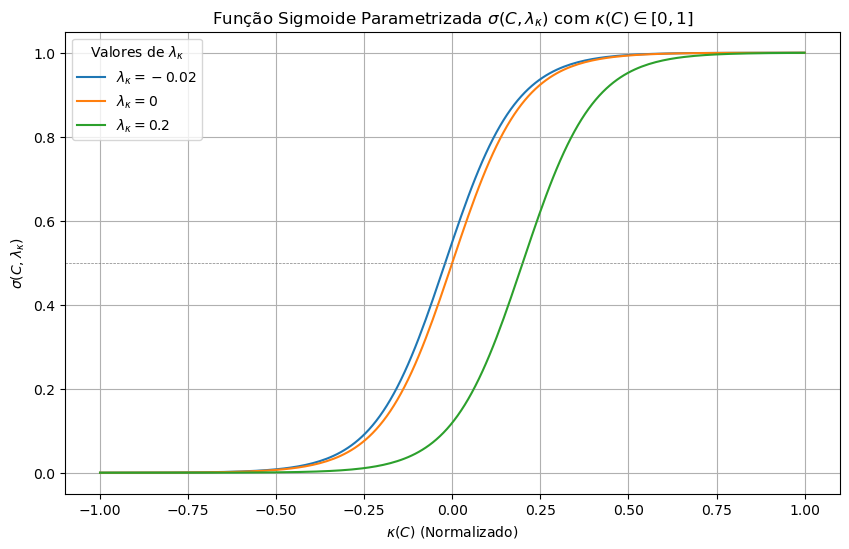

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Função sigmoide parametrizada com normalização de kappa(C) no intervalo [0, 1]
def sigmoid(kappa_C, lambda_kappa, alpha=1):
    return 1 / (1 + np.exp(-alpha * (kappa_C - lambda_kappa)))

# Valores de kappa(C) no intervalo [0, 1]
kappa_C_values = np.linspace(-1, 1, 200)  # Normalizado entre 0 e 1

# Configuração do gráfico
plt.figure(figsize=(10, 6))

# Plotando a função sigmoide para diferentes valores de lambda_kappa e alpha
lambda_kappa_values = [-0.02, 0, 0.2]  # Diferentes pontos de transição
alpha = 10  # Valor alto de alpha para uma transição mais acentuada

for lambda_kappa in lambda_kappa_values:
    sigmoid_values = sigmoid(kappa_C_values, lambda_kappa, alpha)
    plt.plot(kappa_C_values, sigmoid_values, label=f'$\\lambda_{{\\kappa}} = {lambda_kappa}$')

# Configurações do gráfico
plt.title(r'Função Sigmoide Parametrizada $\sigma(C, \lambda_{\kappa})$ com $\kappa(C) \in [0, 1]$')
plt.xlabel(r'$\kappa(C)$ (Normalizado)')
plt.ylabel(r'$\sigma(C, \lambda_{\kappa})$')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5)  # Linha de referência no meio
plt.legend(title=r'Valores de $\lambda_{\kappa}$')
plt.grid(True)
plt.show()


In [13]:
def sigmoid(kappa_C, lambda_kappa, alpha=5):
    return np.round(1 / (1 + np.exp(-alpha * (kappa_C - lambda_kappa))),3)


attr_type = dic['BOX_HEIGHT']
attr_mintree = attrs_mintree[:,attr_type]
#imgFilteredMaxtree = filterMaxtree.filteringDirectRule(att_maxtree > threshold)


In [15]:
from PrettyPrint import PrettyPrintTree
from colorama import Fore, Back
printTree = PrettyPrintTree(
    lambda node: node.children,
#    lambda node: ("id:" + str(node.id) + " " + str(node.isMaxtree)[0], "level:" + str(node.level) + " (" + str(node.residue) + ")", "|cnps|:" + str(len(node.cnps))  ), 
    lambda node: ("id:" + str(node.id) ), 
    color=Back.BLACK + Fore.WHITE
)

In [17]:
printTree(tos.root)

sum=0
for node in tos.listNodes:
    sum += len(node.cnps)
sum, (num_rows * num_cols)

         id:0 
          |
         id:1 
          |
         id:2 
     ┌────┴─────┐
    id:3       id:6 
  ┌──┴───┐      |   
 id:4   id:5   id:7 


(255, 255)

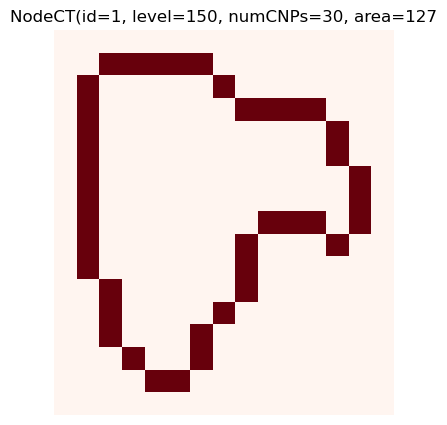

In [23]:
def plotCountors(pixels, node, num_rows, num_cols):
    contour_img = np.zeros((num_rows, num_cols), dtype=np.uint8)
    
    for p in pixels:
        row = p // num_cols
        col = p % num_cols
        contour_img[row, col] = 255  
    
    # Plotar com matplotlib
    plt.figure(figsize=(5, 5))
    plt.imshow(contour_img, cmap='Reds')
    plt.title(node)
    plt.axis('off')
    plt.show()

mtContours = mmcfilters.Attribute.extractContours(tos)
for node, contour in mtContours.contours():
    if (node.area > 100):
        plotCountors(contour, node, num_rows, num_cols)

In [25]:
printTree(maxtree.root)
sum=0
for node in maxtree.listNodes:
    sum += len(node.cnps)
sum, (num_rows * num_cols)

    id:0 
     |
    id:1 
     |
    id:2 
     |
    id:3 
  ┌──┴───┐
 id:4   id:5 


(255, 255)

In [27]:
printTree(mintree.root)
sum=0
for node in mintree.listNodes:
    sum += len(node.cnps)
sum, (num_rows * num_cols)

    id:0 
     |
    id:1 
     |
    id:2 
  ┌──┴───┐
 id:3   id:5 
  |      |   
 id:4   id:6 


(255, 255)

Text(0.5, 1.0, 'attribute filter (tos)')

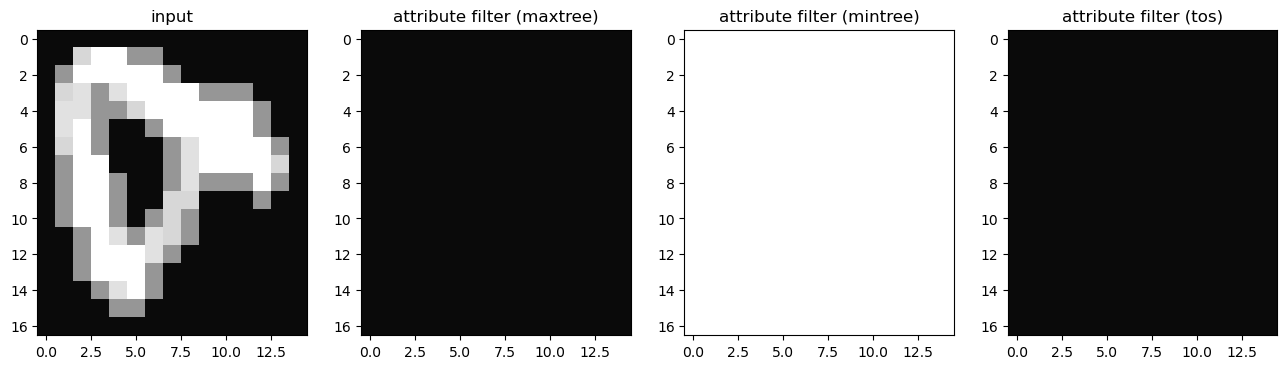

In [29]:
attr_type = dic['BOX_HEIGHT']
threshold = 50

att_maxtree = attrs_maxtree[:,attr_type]
att_mintree = attrs_mintree[:,attr_type]
att_tos = attrs_tos[:,attr_type]

imgFilteredMaxtree = filterMaxtree.filteringDirectRule(att_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringDirectRule(att_mintree > threshold)
imgFilteredToS = filterToS.filteringDirectRule(att_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

Text(0.5, 1.0, 'attribute filter (tos)')

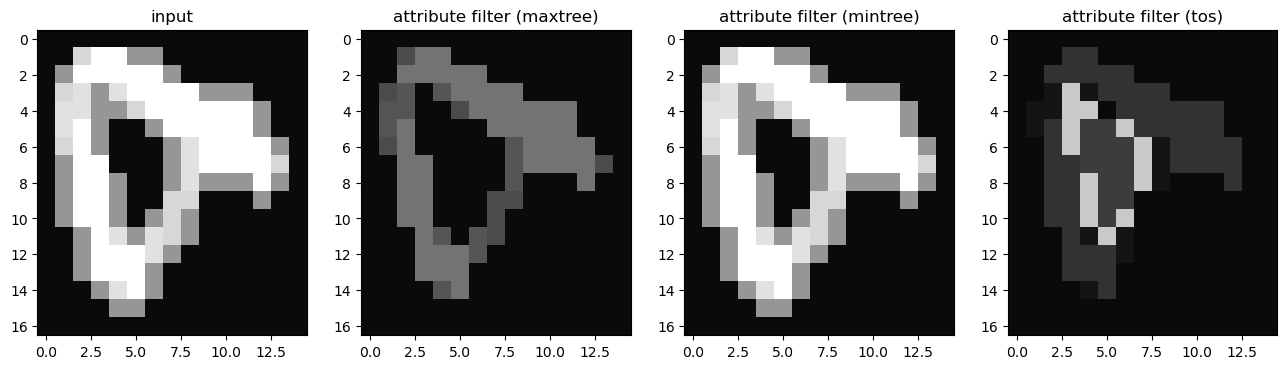

In [33]:
attr_type = dic['INERTIA']
threshold = 0.2

att_maxtree = attrs_maxtree[:,attr_type]
att_mintree = attrs_mintree[:,attr_type]
att_tos = attrs_tos[:,attr_type]

imgFilteredMaxtree = filterMaxtree.filteringSubtractiveRule(att_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringSubtractiveRule(att_mintree > threshold)
imgFilteredToS = filterToS.filteringSubtractiveRule(att_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

Text(0.5, 1.0, 'negative residues')

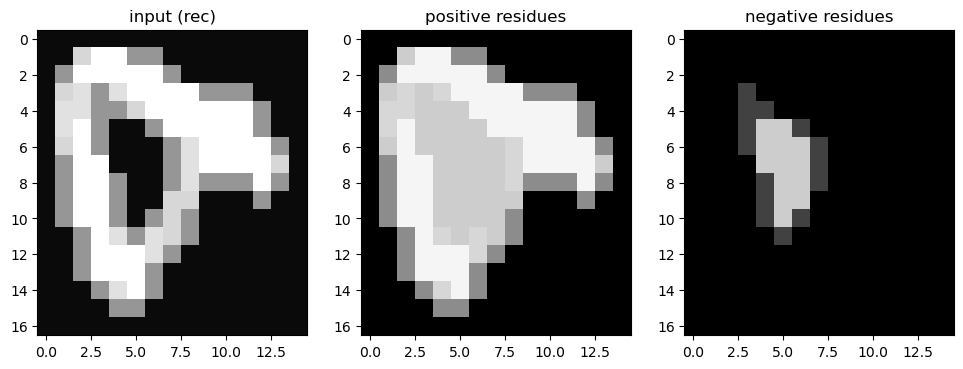

In [35]:
attr_type = dic['BOX_HEIGHT']
max_threshold = 300
attr_tos = attrs_tos[:,attr_type]
deltaMSER=5
primitives = mmcfilters.AttributeOpeningPrimitivesFamily(tos, attr_tos, max_threshold)

rtree = mmcfilters.ResidualTree(primitives)
imgRest = primitives.restOfImage
imgRec = rtree.reconstruction()
imgPos = rtree.getPositiveResidues()
imgNeg = rtree.getNegativeResidues()

plt.subplot(1,4, 1)
plt.imshow(imgRec.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('input (rec)')

plt.subplot(1,4, 2)
plt.imshow(imgPos.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('positive residues')

plt.subplot(1,4, 3)
plt.imshow(imgNeg.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('negative residues')


Text(0.5, 1.0, 'residual filter')

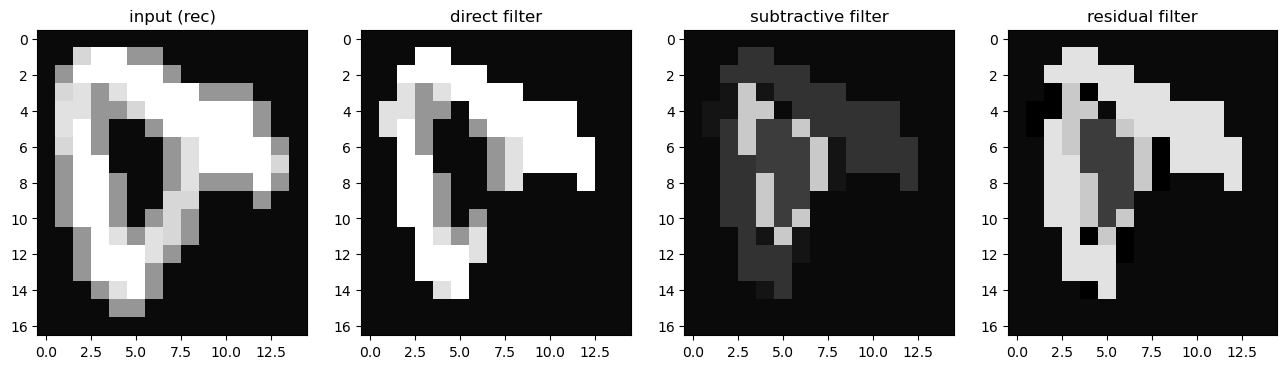

In [37]:
attr_type = dic['INERTIA']
threshold = 0.18
att_tos = attrs_tos[:,attr_type]

filterToS = mmcfilters.AttributeFilters(tos)
imgAttrFilter = filterToS.filteringDirectRule(att_tos > threshold)
imgAttrSub = filterToS.filteringSubtractiveRule(att_tos > threshold)

rtree = mmcfilters.ResidualTree(primitives)
imgResFilter = rtree.filtering(att_tos > threshold)

imgRec = rtree.reconstruction()

plt.subplot(1,4, 1)
plt.imshow(imgRec.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('input (rec)')

plt.subplot(1,4, 2)
plt.imshow(imgAttrFilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('direct filter')

plt.subplot(1,4, 3)
plt.imshow(imgAttrSub.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('subtractive filter')


plt.subplot(1,4, 4)
plt.imshow(imgResFilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('residual filter')
